In [1]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
from cycler import cycler

# Get the current color cycle
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

In [3]:
plt.style.use("seaborn-v0_8-muted")
def set_size(width_pt=472.31595, fraction=1, subplots=(1, 1)):
    """Set figure dimensions nicely

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5 ** .5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return fig_width_in, fig_height_in

# Colormap with University colors
colors = ["white", "#005f9b", "#153268"]
nodes = [0.0, 0.8, 1.0]
unimap = matplotlib.colors.LinearSegmentedColormap.from_list("unimap", list(zip(nodes, colors)))
unimap_r = unimap.reversed()
try:
    matplotlib.colormaps.register(cmap=unimap)
    matplotlib.colormaps.register(cmap=unimap_r)
except ValueError:
    pass

# LaTeX text renderer
plt.rcParams.update({
    "font.family": "serif",  # use serif/main font for text elements
    "font.serif": "Computer Modern Roman",
    "text.usetex": True,  # use inline math for ticks
    "text.latex.preamble": r"\usepackage{amsmath}",
    "pgf.rcfonts": False,  # don't setup fonts from rc parameters
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 10.95,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    # Cmap
    "image.cmap": "unimap"
})

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['axes.prop_cycle'] = mpl.cycler(color=mpl.cm.Set2(range(8)))

COLORS = mpl.cycler(color=mpl.cm.Set2(range(8)))

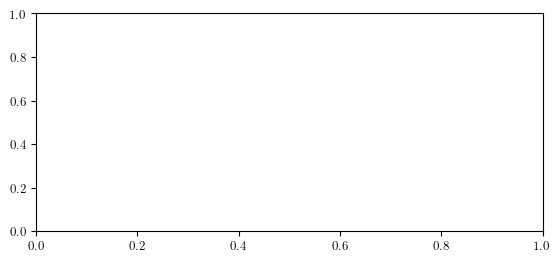

In [5]:
fig, ax1 = plt.subplots(1, 1, figsize=set_size(fraction=1, subplots=(0.7, 1)), sharex=True)



In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

In [9]:
files = os.listdir("fluo_01")
files_sorted = sorted(files, key=lambda f: int(os.path.splitext(f)[0]))
print(files_sorted)

['49.png', '149.png', '449.png', '1399.png', '2399.png', '4399.png', '6399.png', '8399.png', '10399.png', '12399.png', '14399.png', '16399.png']


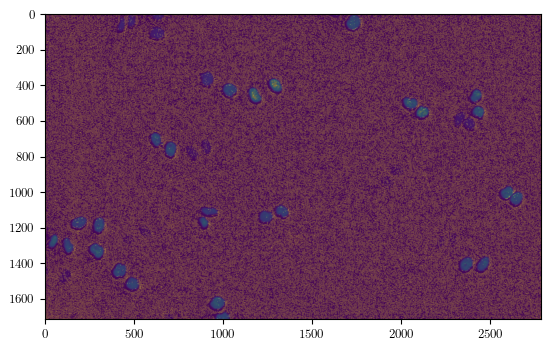

In [74]:
plt.imshow(img[326:2400-360, 452:3600-361])

In [76]:
import pandas as pd

In [95]:
ptloss

,Wall time,Step,Value
0,1.762000e+09,18,0.001712
1,1.762000e+09,42,0.001623
2,1.762000e+09,45,0.000998
3,1.762000e+09,56,0.000344
4,1.762000e+09,71,0.000205
...,...,...,...
995,1.762171e+09,18318,0.000005
996,1.762171e+09,18321,0.000005
997,1.762172e+09,18362,0.000005
998,1.762172e+09,18370,0.000005


In [79]:
ptloss = pd.read_csv("../final_pretrain_loss/Fluo-N2DL-HeLa_exp_2025-11-01_13-20-06.csv")

In [117]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['axes.prop_cycle'] = mpl.cycler(color=mpl.cm.Set2(range(8)))

COLORS = mpl.cycler(color=mpl.cm.Set2(range(8)))

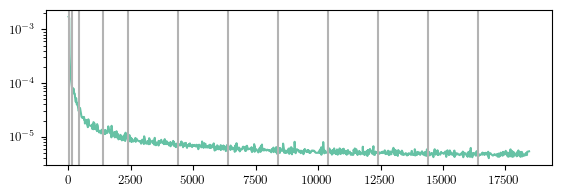

In [129]:
fig, ax = plt.subplots(1, 1, figsize=set_size(fraction=1, subplots=(1,2)))


ax.plot(ptloss["Step"].to_numpy(), ptloss["Value"].to_numpy())
ax.set_yscale("log")

for xloc in [int(x.split(".")[0]) for x in files_sorted]:
    ax.axvline(x = xloc, color = list(COLORS)[7]['color'], label = 'axvline - full height')

plt.savefig("clustering checkpoints.pdf")

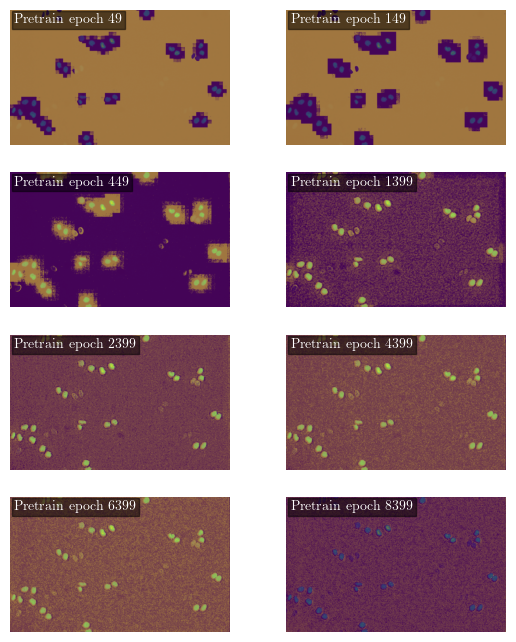

In [119]:
fig, ax = plt.subplots(4, 2, figsize=set_size(fraction=1, subplots=(4,2)))

for idx in range(8):
    img = np.array(Image.open('fluo_01/' + files_sorted[idx]))
    ax.flat[idx].imshow(img[326:2400-360, 452:3600-361])

    ax.flat[idx].text(
        0.02, 0.97, "Pretrain epoch "+files_sorted[idx].split(".")[0],
        transform=ax.flat[idx].transAxes,
        ha='left', va='top',
        color='white', fontsize=10,
        bbox=dict(facecolor='black', alpha=0.5, pad=2)
    )


    ax.flat[idx].set_axis_off()

#fig.savefig('qualitative_fluo.pdf', format='pdf', bbox_inches='tight', dpi=300)